## Кластерный анализ данных о бронированиях Expedia

---
### Ссылки
1. [Изучение данных](#1)
2. [Исследовательский анализ данных и разработка признаков](#2)
3. [Кластерный анализ](#3)
4. [Вывод по кластеризации](#4)
---

# 1. Изучение данных
<a id="1"></a>

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import pandas as pd
pd.set_option('display.max_columns',None)
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import LabelEncoder,StandardScaler,MinMaxScaler
from sklearn import preprocessing,cluster
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans,AgglomerativeClustering
from sklearn.metrics import silhouette_samples,silhouette_score,davies_bouldin_score
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import confusion_matrix,roc_auc_score,roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso,LogisticRegression

from xgboost import XGBClassifier

from yellowbrick.cluster import KElbowVisualizer
from yellowbrick.cluster import SilhouetteVisualizer

import statsmodels as sm
from scipy import stats

from time import time

from imblearn.under_sampling import RandomUnderSampler

from warnings import simplefilter
simplefilter("ignore")

In [2]:
#plt.style.use('ggplot')

In [3]:
data = pd.read_csv('travel.csv')

In [4]:
data.head()

,Unnamed: 0,date_time,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,channel,srch_ci,srch_co,srch_adults_cnt,srch_children_cnt,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster
0,24636210,2014-11-03 16:02:28,24,2,77,871,36643,456.1151,792280,0,1,1,2014-12-15,2014-12-19,2,0,1,8286,1,0,1,0,63,1258,68
1,19837144,2013-03-13 19:25:01,11,3,205,135,38749,232.4737,961995,0,0,9,2013-03-13,2013-03-14,2,0,1,1842,3,0,1,2,198,786,37
2,13066459,2014-10-13 13:20:25,2,3,66,314,48562,4468.2720,495669,0,1,9,2015-04-03,2015-04-10,2,0,1,8746,1,0,1,6,105,29,22
3,4691082,2013-11-05 10:40:34,11,3,205,411,52752,171.6021,106611,0,0,0,2013-11-07,2013-11-08,2,0,1,6210,3,1,1,2,198,1234,42
4,4878884,2014-06-10 13:34:56,2,3,66,174,50644,NaN,596177,0,0,9,2014-08-03,2014-08-08,2,1,1,12812,5,0,1,2,50,368,83


**Значения столбцов**
1. **date_time**: Временная метка (дата и время события)
2. **site_name**: ID точки продаж Expedia
3. **posa_continent**: ID континента, связанного с точкой продаж (site_name)
4. **user_location_country**: ID страны, в которой находится клиент
5. **user_location_region**: ID региона, в котором находится клиент
6. **user_location_city**: ID города, в котором находится клиент
7. **orig_destination_distance**: Физическое расстояние между отелем и клиентом на момент поиска
8. **user_id**: ID клиента
9. **is_mobile**: 1, если пользователь подключился с мобильного устройства, 0 — в противном случае
10. **is_package**: 1, если клик/бронирование было совершено в составе пакета услуг, 0 — в противном случае
11. **channel**: ID маркетингового канала
12. **srch_ci**: Дата заезда (check-in)
13. **srch_co**: Дата выезда (check-out)
14. **srch_adults_cnt**: Количество взрослых в номере отеля
15. **srch_children_cnt**: Количество детей в номере отеля
16. **srch_rm_cnt**: Количество номеров отеля в поисковом запросе
17. **srch_destination_id**: ID пункта назначения
18. **srch_destination_type_id**: Тип пункта назначения
19. **is_booking**: 1, если произошло бронирование, 0, если только клик — **целевая переменная**
20. **cnt**: Количество похожих событий в контексте одной сессии пользователя
21. **hotel_continent**: Континент, где расположен отель
22. **hotel_country**: Страна, где расположен отель
23. **hotel_market**: Рынок отеля
24. **hotel_cluster**: ID кластера отелей

In [5]:
print(f"В датасете есть {data.shape[0]} строк (значений) и {data.shape[1]} столбцов (признаков).")

В датасете есть 100000 строк (значений) и 25 столбцов (признаков).


**Пропущенные значения и дубликаты**

In [6]:
print(f"Пропущенные значения: {data.isnull().sum()}")

Пропущенные значения: Unnamed: 0                       0
date_time                        0
site_name                        0
posa_continent                   0
user_location_country            0
user_location_region             0
user_location_city               0
orig_destination_distance    36085
user_id                          0
is_mobile                        0
is_package                       0
channel                          0
srch_ci                        122
srch_co                        122
srch_adults_cnt                  0
srch_children_cnt                0
srch_rm_cnt                      0
srch_destination_id              0
srch_destination_type_id         0
is_booking                       0
cnt                              0
hotel_continent                  0
hotel_country                    0
hotel_market                     0
hotel_cluster                    0
dtype: int64


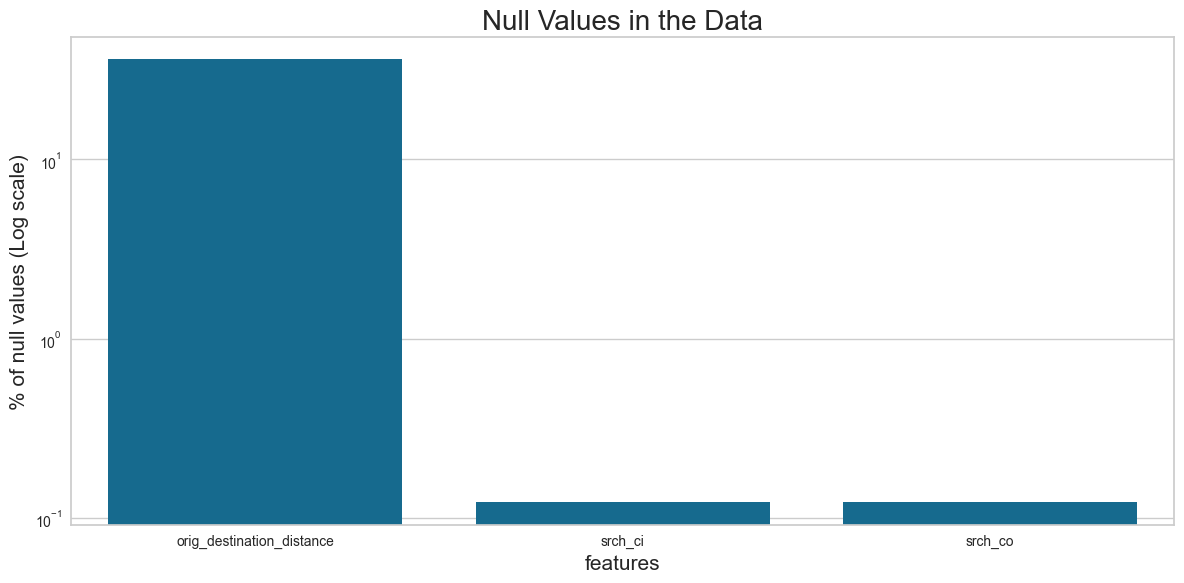

In [7]:
def plot_nulls(data,title,x_axis_label,y_axis_label):
    data_nulls = (data.apply(lambda x:x.isnull().value_counts()).T[True]/len(data)*100).reset_index(name='count')

    plt.figure(figsize=(12,6))
    sns.barplot(data_nulls.loc[data_nulls['count'] > 0],x="index",y="count")
    plt.yscale('log')
    plt.title(title,fontsize=20)
    plt.xlabel(x_axis_label,fontsize=15)
    plt.ylabel(y_axis_label,fontsize=15)
    
    
    plt.tight_layout()
    plt.show()
    
    
plot_nulls(data,"Null Values in the Data",'features','% of null values (Log scale)')  

Можно увидеть много пропущенных значений в orig_destination_distance и одинаковое количество пропусков в srch_ci и srch_co.

In [8]:
print(f"В текущем датасете {data.duplicated().sum()} повторяющихся значений.")

В текущем датасете 0 повторяющихся значений.


In [9]:
print(f"Число уникальныъ значений в датасете: \n\n {data.nunique()}")

Число уникальныъ значений в датасете: 

 Unnamed: 0                   100000
date_time                     99886
site_name                        41
posa_continent                    5
user_location_country           201
user_location_region            779
user_location_city            10779
orig_destination_distance     62206
user_id                       88863
is_mobile                         2
is_package                        2
channel                          11
srch_ci                        1066
srch_co                        1068
srch_adults_cnt                  10
srch_children_cnt                10
srch_rm_cnt                       9
srch_destination_id            8827
srch_destination_type_id          8
is_booking                        2
cnt                              32
hotel_continent                   7
hotel_country                   178
hotel_market                   1843
hotel_cluster                   100
dtype: int64


In [10]:
data.describe()

,Unnamed: 0,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,channel,srch_adults_cnt,srch_children_cnt,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,63915.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.882530e+07,9.838570,2.678150,85.995070,308.636990,27676.391240,1960.661721,6.054383e+05,0.133770,0.248140,5.858590,2.020710,0.336750,1.111750,14426.32738,2.577290,0.079930,1.487980,3.150920,81.093290,598.848330,49.860370
std,1.086183e+07,11.996426,0.749018,59.292002,208.706581,16768.647409,2228.153377,3.516154e+05,0.340407,0.431936,3.722823,0.909774,0.734449,0.451602,11036.98122,2.149263,0.271186,1.280262,1.620534,56.111519,510.959297,28.885423
min,1.012000e+03,2.000000,0.000000,0.000000,0.000000,0.000000,0.005600,1.400000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.00000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,9.448967e+06,2.000000,3.000000,66.000000,174.000000,12949.000000,312.792100,2.987962e+05,0.000000,0.000000,2.000000,2.000000,0.000000,1.000000,8267.00000,1.000000,0.000000,1.000000,2.000000,50.000000,158.000000,25.000000
50%,1.881212e+07,2.000000,3.000000,66.000000,314.000000,27655.000000,1131.835300,6.028825e+05,0.000000,0.000000,9.000000,2.000000,0.000000,1.000000,9145.00000,1.000000,0.000000,1.000000,2.000000,50.000000,591.000000,49.000000
75%,2.825307e+07,15.000000,3.000000,70.000000,385.000000,42328.000000,2542.359350,9.157222e+05,0.000000,0.000000,9.000000,2.000000,0.000000,1.000000,18784.00000,5.000000,0.000000,2.000000,4.000000,106.000000,701.000000,73.000000
max,3.767009e+07,53.000000,4.000000,239.000000,1025.000000,56507.000000,11965.376100,1.198783e+06,1.000000,1.000000,10.000000,9.000000,9.000000,8.000000,65035.00000,9.000000,1.000000,120.000000,6.000000,212.000000,2117.000000,99.000000


Можно заметить, что:
- в датасете есть колонка **'Unnamed: 0'**, чьё значение не является понятным. Я уберу её.
- здесь есть даты (столбцы: 'date_time', 'srch_ci', 'srch_co') которые нужно либо переконвертировать в другой формат, либо разбить на год, день и месяц.
- имеются большие значения, которые следует перемасштабировать.

Корреляционая тепловая карта.

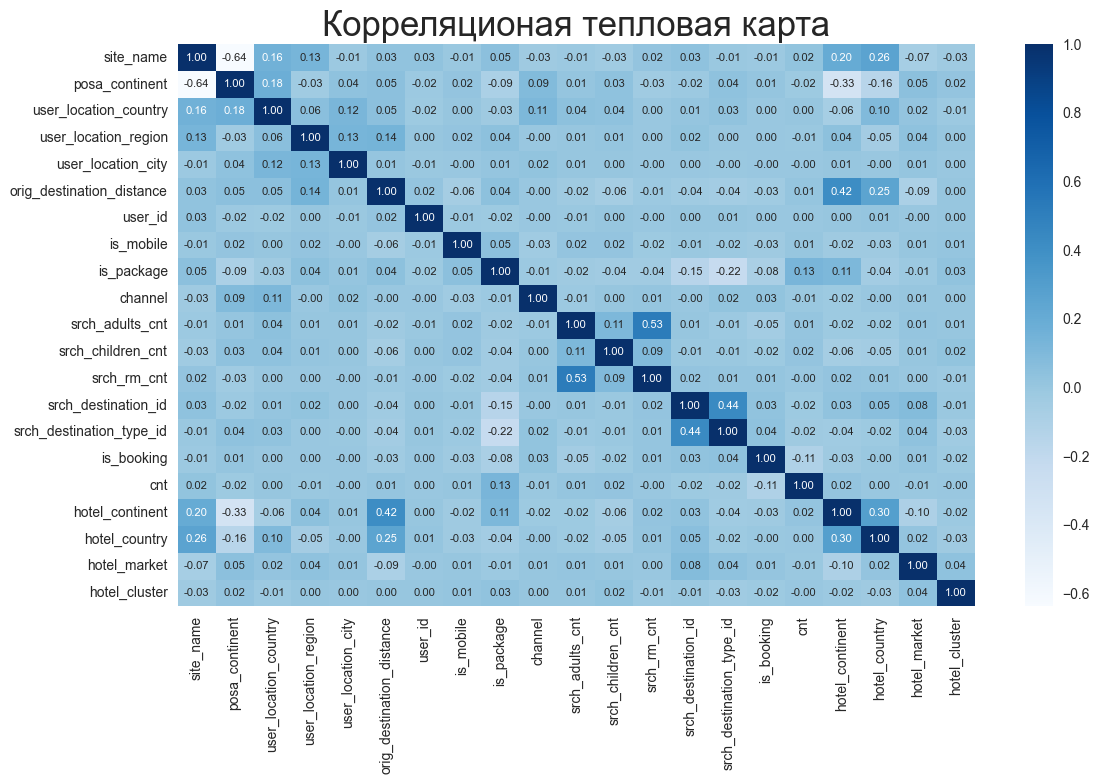

In [11]:
corr_travel = data.drop(['Unnamed: 0','date_time','srch_ci','srch_co'],axis=1)

plt.figure(figsize=(12,8))
sns.heatmap(corr_travel.corr(method='pearson'),annot=True,fmt='.2f',annot_kws={"fontsize":8},cmap='Blues')
plt.title('Корреляционая тепловая карта',fontsize=25)

plt.tight_layout()
plt.show()

Между переменными наблюдается несколько относительно сильных корреляций. Однако ни одна из них не имеет коэффициента Пирсона с абсолютным значением выше 0,65.

# 2. Исследовательский анализ данных и разработка признаков
<a id="2"></a>

## Важность признаков

In [16]:
sample = data.sample(n=20000, random_state=42)

X = sample.drop(columns=['hotel_cluster', 'date_time', 'srch_ci', 'srch_co'])
y = sample['hotel_cluster']

X = X.fillna(X.median())

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

feat_imp.head(10)

,feature,importance
20,hotel_market,0.133627
14,srch_destination_id,0.112354
19,hotel_country,0.092248
6,orig_destination_distance,0.074183
18,hotel_continent,0.071644
7,user_id,0.070336
0,Unnamed: 0,0.068806
5,user_location_city,0.061658
4,user_location_region,0.058317
3,user_location_country,0.037365


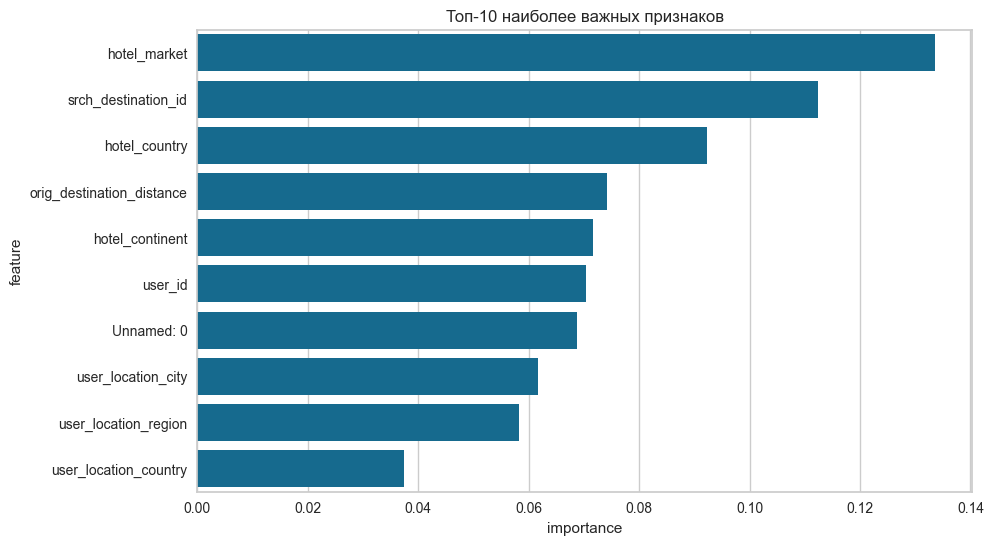

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp.head(10), x='importance', y='feature')
plt.title('Топ-10 наиболее важных признаков')
plt.show()

Для оценки значимости признаков была обучена модель Random Forest.
В качестве входных данных использовались числовые признаки после обработки пропусков и масштабирования.
Важность признаков определялась на основе величины feature_importances_.

Наиболее значимыми признаками оказались:

- srch_destination_id
- hotel_country
- hotel_market
- orig_destination_distance
- user_location_country

Эти признаки оказывают наибольшее влияние на формирование кластеров отелей и отражают географические характеристики пользователя и направления поездки.
Менее значимыми оказались бинарные признаки (is_mobile, is_package), что говорит о слабом влиянии типа устройства и способа бронирования на сегментацию клиентов.

## 2.1 Распределение числовых переменных

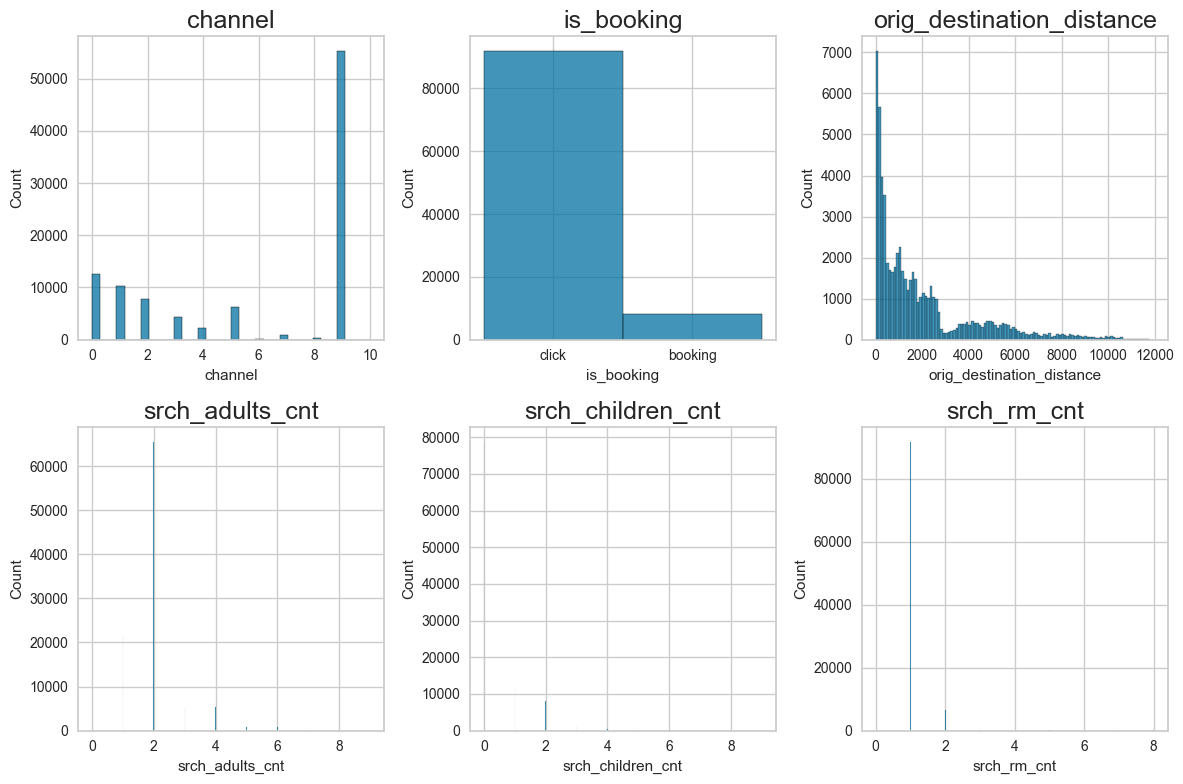

In [12]:
plotted_columns = data[['channel','is_booking','orig_destination_distance','srch_adults_cnt','srch_children_cnt','srch_rm_cnt']]
plotted_columns['is_booking'] = plotted_columns['is_booking'].map({1:'booking',0:'click'})

fig,axes = plt.subplots(nrows=2,ncols=3,figsize=(12,8))    
axes = axes.flatten()         

for ax,col in zip(axes,plotted_columns.columns):
  sns.histplot(plotted_columns[col],ax=ax)
  ax.set_title(col,size=18)
  plt.tight_layout()  

Некоторые графики здесь кажутся пустыми, почему то столбцы в них оказываются слишком тонкими.

Эти графики показывают, что:
* Как и ожидалось, подавляющее большинство действий, совершаемых клиентами (или, скорее, потенциальными клиентами), - это «клики».

* Большинство интересующих их мест находятся на расстоянии менее 2000 километров (или миль?) от клиента.

* Большинство клиентов искали двухместный номер (для двух взрослых).

## 2.2 Количество действий (клики и бронирования)

В приведённом ниже коде высчитывется общее количество действий (клики + бронирования) на каждого клиента.

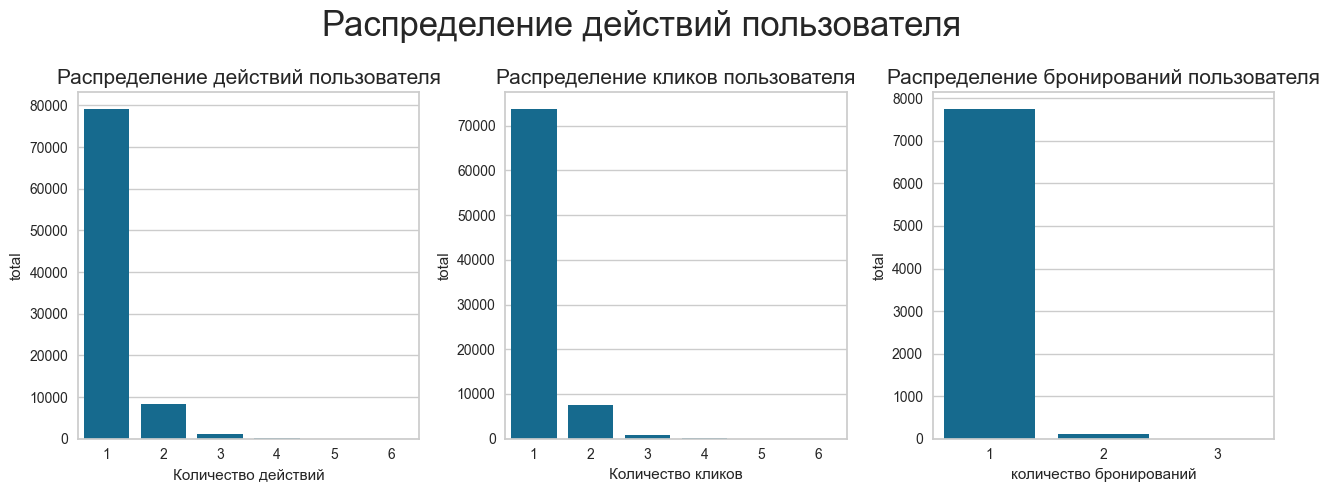

In [13]:
##########################
user_actions = data.groupby(['user_id'])['is_booking'].count().reset_index(name='action_count')

tot_user_actions = user_actions.groupby('action_count')['action_count'].count().reset_index(name='total')

user_clicks = data.loc[data.is_booking == 0].groupby(['user_id'])['is_booking'].count().reset_index(name='click_count')

tot_user_clicks = user_clicks.groupby('click_count')['click_count'].count().reset_index(name='total')

user_bookings = data.loc[data.is_booking == 1].groupby(['user_id'])['is_booking'].count().reset_index(name='booking_count')

tot_user_bookings = user_bookings.groupby('booking_count')['booking_count'].count().reset_index(name='total')
##########################

fig,(ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(13,5))

ax1 = sns.barplot(data=tot_user_actions,x='action_count',y='total',ax=ax1)
ax1.set_xlabel('Количество действий')
ax1.set_title("Распределение действий пользователя",size=15)

ax2 = sns.barplot(data=tot_user_clicks,x='click_count',y='total',ax=ax2)
ax2.set_xlabel('Количество кликов')
ax2.set_title("Распределение кликов пользователя",size=15)

ax3 = sns.barplot(data=tot_user_bookings,x='booking_count',y='total',ax=ax3)
ax3.set_xlabel('количество бронирований')
ax3.set_title("Распределение бронирований пользователя",size=15)

plt.suptitle("Распределение действий пользователя",size=25)

plt.tight_layout()

Приведенные выше графики показывают распределение общего числа действий (кликов + бронирований) на пользователя, а также распределение общего числа кликов и бронирований на пользователя. Как и ожидалось, большинство пользователей просто кликали, не совершая бронирований. Очень немногие из них совершили более одного действия/клика/бронирования.

Добавим эти данные в наш датафрейм. У каждого пользователя теперь также будут иметься его количество действий/кликов/бронирований.

In [14]:
data = data.merge(user_actions,on='user_id',how='left')
data = data.merge(user_clicks,on='user_id',how='left')
data = data.merge(user_bookings,on='user_id',how='left')

В строках с одним действием и одним кликом или бронированием в одном из столбцов, содержащих клик или бронирование, может быть пустое значение. Заполним эти пустые значения нулями.

In [15]:
data['click_count'].isnull().sum(), data['booking_count'].isnull().sum()

(np.int64(6680), np.int64(90484))

In [16]:
data['click_count']   = data['click_count'].fillna(0)
data['booking_count'] = data['booking_count'].fillna(0)

data['click_count'].isnull().sum(), data['booking_count'].isnull().sum()

(np.int64(0), np.int64(0))

In [17]:
data.head()

,Unnamed: 0,date_time,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,channel,srch_ci,srch_co,srch_adults_cnt,srch_children_cnt,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster,action_count,click_count,booking_count
0,24636210,2014-11-03 16:02:28,24,2,77,871,36643,456.1151,792280,0,1,1,2014-12-15,2014-12-19,2,0,1,8286,1,0,1,0,63,1258,68,2,2.0,0.0
1,19837144,2013-03-13 19:25:01,11,3,205,135,38749,232.4737,961995,0,0,9,2013-03-13,2013-03-14,2,0,1,1842,3,0,1,2,198,786,37,1,1.0,0.0
2,13066459,2014-10-13 13:20:25,2,3,66,314,48562,4468.2720,495669,0,1,9,2015-04-03,2015-04-10,2,0,1,8746,1,0,1,6,105,29,22,1,1.0,0.0
3,4691082,2013-11-05 10:40:34,11,3,205,411,52752,171.6021,106611,0,0,0,2013-11-07,2013-11-08,2,0,1,6210,3,1,1,2,198,1234,42,2,1.0,1.0
4,4878884,2014-06-10 13:34:56,2,3,66,174,50644,NaN,596177,0,0,9,2014-08-03,2014-08-08,2,1,1,12812,5,0,1,2,50,368,83,1,1.0,0.0


Давайте проверим результат обновления нашего датафрейма, рассмотрев случайного пользователя. Например, посмотрим на значение 'user_id' = 106611.

In [18]:
data[data['user_id'] == 106611]

,Unnamed: 0,date_time,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,channel,srch_ci,srch_co,srch_adults_cnt,srch_children_cnt,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster,action_count,click_count,booking_count
3,4691082,2013-11-05 10:40:34,11,3,205,411,52752,171.6021,106611,0,0,0,2013-11-07,2013-11-08,2,0,1,6210,3,1,1,2,198,1234,42,2,1.0,1.0
76497,4691128,2014-07-22 12:22:25,11,3,205,411,54864,209.6633,106611,0,0,0,2014-07-29,2014-08-01,1,0,1,9819,3,0,2,2,198,1234,90,2,1.0,1.0


Имеется две строки. Первая соответствует бронированию ('is_booking' = 1), вторая — клику ('is_booking' = 0). Таким образом, 'action_count' этого пользователя равен 2, а 'click_count' = 'booking_count' = 1.

## 2.3 Логические проверки

Количество гостей должно быть больше 0. Кроме того, дети не могут путешествовать одни. Ряды, не соответствующие этим ограничениям, должны быть исключены.

In [19]:
data_count0 = data.loc[((data.srch_adults_cnt) + (data.srch_children_cnt)) == 0]

data_count0

,Unnamed: 0,date_time,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,channel,srch_ci,srch_co,srch_adults_cnt,srch_children_cnt,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster,action_count,click_count,booking_count
115,11473397,2014-10-07 14:43:37,2,3,66,293,52284,NaN,909952,0,1,9,2015-01-10,2015-01-15,0,0,1,8250,1,0,1,2,50,628,1,1,1.0,0.0
496,24467491,2013-06-15 19:12:59,29,1,52,40,29080,NaN,150434,0,1,9,2013-09-16,2013-09-20,0,0,2,25408,6,0,2,6,15,1534,46,1,1.0,0.0
1261,9475782,2014-10-26 10:20:35,2,3,66,220,22648,5148.4830,588617,1,1,2,2015-08-24,2015-09-03,0,0,1,8746,1,0,1,6,105,29,78,1,1.0,0.0
1428,17753458,2014-11-16 10:21:59,2,3,66,174,53801,1638.7472,207522,1,1,0,2015-04-18,2015-04-25,0,0,1,8810,1,0,1,4,8,1532,52,1,1.0,0.0
1539,8869536,2014-12-28 19:16:12,2,3,66,363,31138,1526.8518,938404,0,1,0,NaN,NaN,0,0,1,8277,1,0,1,2,50,412,9,1,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95299,35675080,2014-03-15 16:49:48,23,1,1,318,2096,1088.1394,1020200,0,1,0,2014-05-24,2014-05-31,0,0,1,22889,1,0,4,6,208,1798,67,1,1.0,0.0
95832,28204609,2014-03-07 11:34:55,2,3,66,324,44585,1356.9140,776221,0,1,1,2014-05-28,2014-06-02,0,0,1,1152,1,0,2,4,47,1502,42,1,1.0,0.0
96165,22532793,2014-08-10 15:09:28,2,3,66,442,28620,767.7554,67291,0,1,5,2014-10-02,2014-10-04,0,0,1,8236,1,0,1,2,50,656,59,2,2.0,0.0
97822,24919526,2014-05-10 00:55:09,2,3,66,153,20706,258.1804,577044,0,1,1,2014-05-11,2014-05-14,0,0,1,8250,1,0,2,2,50,628,47,1,1.0,0.0


In [20]:
data_children_alone = data.loc[data.srch_adults_cnt == 0]

data_children_alone

,Unnamed: 0,date_time,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,channel,srch_ci,srch_co,srch_adults_cnt,srch_children_cnt,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster,action_count,click_count,booking_count
115,11473397,2014-10-07 14:43:37,2,3,66,293,52284,NaN,909952,0,1,9,2015-01-10,2015-01-15,0,0,1,8250,1,0,1,2,50,628,1,1,1.0,0.0
496,24467491,2013-06-15 19:12:59,29,1,52,40,29080,NaN,150434,0,1,9,2013-09-16,2013-09-20,0,0,2,25408,6,0,2,6,15,1534,46,1,1.0,0.0
545,20749225,2014-09-25 09:14:45,2,3,63,451,14872,NaN,14297,0,1,1,2014-10-21,2014-10-24,0,2,1,8253,1,0,2,6,70,19,69,1,1.0,0.0
1261,9475782,2014-10-26 10:20:35,2,3,66,220,22648,5148.4830,588617,1,1,2,2015-08-24,2015-09-03,0,0,1,8746,1,0,1,6,105,29,78,1,1.0,0.0
1428,17753458,2014-11-16 10:21:59,2,3,66,174,53801,1638.7472,207522,1,1,0,2015-04-18,2015-04-25,0,0,1,8810,1,0,1,4,8,1532,52,1,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95832,28204609,2014-03-07 11:34:55,2,3,66,324,44585,1356.9140,776221,0,1,1,2014-05-28,2014-06-02,0,0,1,1152,1,0,2,4,47,1502,42,1,1.0,0.0
96165,22532793,2014-08-10 15:09:28,2,3,66,442,28620,767.7554,67291,0,1,5,2014-10-02,2014-10-04,0,0,1,8236,1,0,1,2,50,656,59,2,2.0,0.0
97822,24919526,2014-05-10 00:55:09,2,3,66,153,20706,258.1804,577044,0,1,1,2014-05-11,2014-05-14,0,0,1,8250,1,0,2,2,50,628,47,1,1.0,0.0
97998,14688274,2014-03-06 20:50:46,2,3,66,256,54612,2319.1694,576373,1,1,9,2014-11-28,2014-12-12,0,0,1,5405,6,0,1,4,8,126,73,1,1.0,0.0


In [21]:
rows_to_drop = pd.concat([data_count0,data_children_alone]).drop_duplicates()

print(f'Количество строк для удаления: {len(rows_to_drop)}') 
print(f'Ожидаемая длина датафрейма после удаления этих строк.: {len(data) - len(rows_to_drop)}')

Количество строк для удаления: 181
Ожидаемая длина датафрейма после удаления этих строк.: 99819


Теперь эти наборы строк будут удалены из набора данных.

In [22]:
data.drop(rows_to_drop.index,inplace=True)

len(data)

99819

## 2.4 Столбцы даты и времени

Поменяем формат столбцов с датами.

In [23]:
data['srch_co']   = pd.to_datetime(data['srch_co'])
data['srch_ci']   = pd.to_datetime(data['srch_ci'])
data['date_time'] = pd.to_datetime(data['date_time'])

data['date'] = pd.to_datetime(data['date_time'].apply(lambda x: x.date()))

data.head()

,Unnamed: 0,date_time,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,channel,srch_ci,srch_co,srch_adults_cnt,srch_children_cnt,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster,action_count,click_count,booking_count,date
0,24636210,2014-11-03 16:02:28,24,2,77,871,36643,456.1151,792280,0,1,1,2014-12-15,2014-12-19,2,0,1,8286,1,0,1,0,63,1258,68,2,2.0,0.0,2014-11-03
1,19837144,2013-03-13 19:25:01,11,3,205,135,38749,232.4737,961995,0,0,9,2013-03-13,2013-03-14,2,0,1,1842,3,0,1,2,198,786,37,1,1.0,0.0,2013-03-13
2,13066459,2014-10-13 13:20:25,2,3,66,314,48562,4468.2720,495669,0,1,9,2015-04-03,2015-04-10,2,0,1,8746,1,0,1,6,105,29,22,1,1.0,0.0,2014-10-13
3,4691082,2013-11-05 10:40:34,11,3,205,411,52752,171.6021,106611,0,0,0,2013-11-07,2013-11-08,2,0,1,6210,3,1,1,2,198,1234,42,2,1.0,1.0,2013-11-05
4,4878884,2014-06-10 13:34:56,2,3,66,174,50644,NaN,596177,0,0,9,2014-08-03,2014-08-08,2,1,1,12812,5,0,1,2,50,368,83,1,1.0,0.0,2014-06-10


Затем я проверяю, наступает ли дата выезда позже даты заезда. Это условие должно быть выполнено.

In [24]:
data = data.loc[data.srch_ci < data.srch_co]

len(data)

99316

Я также проверяю, не приходится ли дата заезда позже даты бронирования. Это условие должно быть соблюдено.

In [25]:
data = data.loc[data.date < data.srch_ci]

len(data)

96355

## 2.5 Продолжительность поездки

Теперь создадим два новых столбца. Первый — это продолжительность поездки, то есть разница между датами выезда и заезда.

In [26]:
data['travel_duration'] = (data.srch_co - data.srch_ci).dt.days

Затем создадим столбец 'days_in_advance', который будет представлять собой разницу между датами заезда и бронирования.

In [27]:
data['days_in_advance'] = (data.srch_ci - data.date).dt.days

In [28]:
data.head()

,Unnamed: 0,date_time,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,channel,srch_ci,srch_co,srch_adults_cnt,srch_children_cnt,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster,action_count,click_count,booking_count,date,travel_duration,days_in_advance
0,24636210,2014-11-03 16:02:28,24,2,77,871,36643,456.1151,792280,0,1,1,2014-12-15,2014-12-19,2,0,1,8286,1,0,1,0,63,1258,68,2,2.0,0.0,2014-11-03,4,42
2,13066459,2014-10-13 13:20:25,2,3,66,314,48562,4468.2720,495669,0,1,9,2015-04-03,2015-04-10,2,0,1,8746,1,0,1,6,105,29,22,1,1.0,0.0,2014-10-13,7,172
3,4691082,2013-11-05 10:40:34,11,3,205,411,52752,171.6021,106611,0,0,0,2013-11-07,2013-11-08,2,0,1,6210,3,1,1,2,198,1234,42,2,1.0,1.0,2013-11-05,1,2
4,4878884,2014-06-10 13:34:56,2,3,66,174,50644,NaN,596177,0,0,9,2014-08-03,2014-08-08,2,1,1,12812,5,0,1,2,50,368,83,1,1.0,0.0,2014-06-10,5,54
6,24023139,2014-01-28 13:16:36,2,3,66,337,54287,329.1833,908558,0,0,2,2014-02-27,2014-03-01,2,0,1,8287,1,1,1,2,198,400,6,1,0.0,1.0,2014-01-28,2,30


## 2.6 Statistical Analysis of Booking Channels

Ниже представлена ​​статистика по различным каналам бронирования. Приведенные цифры включают:
* Количество взаимодействий, то есть общее число взаимодействий пользователей с данным каналом бронирования, включая как клики, так и бронирования.

* Количество бронирований, то есть просто общее число бронирований в рамках данного канала.

* Средний коэффициент бронирования по каналам, то есть соотношение между количеством бронирований и взаимодействий в рамках данного канала.

In [29]:
booking_channels = data.groupby('channel')['is_booking'].mean().reset_index(name='avg_booking')

interaction_count = data.groupby('channel')['is_booking'].count().reset_index(name='interaction_count')

booking_count = data.loc[data.is_booking == 1].groupby('channel')['is_booking'].count().reset_index(name='booking_count')

booking_channels = booking_channels.merge(booking_count,on='channel')
booking_channels = booking_channels.merge(interaction_count,on='channel').sort_values('interaction_count',ascending=False)

booking_channels

,channel,avg_booking,booking_count,interaction_count
9,9,0.081580,4334,53126
0,0,0.068320,821,12017
1,1,0.066862,663,9916
2,2,0.059858,456,7618
5,5,0.093293,562,6024
3,3,0.060423,260,4303
4,4,0.116737,249,2133
7,7,0.044643,35,784
8,8,0.050000,13,260
6,6,0.069182,11,159


Эти числа могут помочь нам определить наиболее эффективные каналы бронирования. Но чтобы точно убедиться в их точности нужно применить z-тестирование и t-тестирование.

In [30]:
def stats_comparison():

    cat = booking_channels[['channel','avg_booking','booking_count']]
    
    overall_average = data['is_booking'].mean()
    overall_bookings = booking_channels['booking_count'].sum()

    cat['rest_bookings'] = overall_bookings - cat['booking_count']
    cat['rest_average'] = (overall_bookings*overall_average - cat['booking_count']*cat['avg_booking'])/cat['rest_bookings']

    cat['z_score'] = (cat['avg_booking']-cat['rest_average'])/np.sqrt(overall_average*(1-overall_average)*(1/cat['booking_count']+1/cat['rest_bookings']))
    cat['prob'] = np.around(stats.norm.cdf(cat.z_score),decimals=10)
    cat['significant'] = [(lambda x: 1 if x > 0.9 else -1 if x < 0.1 else 0)(i) for i in cat['prob']]
    
    return cat


stats = stats_comparison()
stats

,channel,avg_booking,booking_count,rest_bookings,rest_average,z_score,prob,significant
9,9,0.081580,4334,3073,0.070233,1.806235,0.964559,1
0,0,0.068320,821,6586,0.077938,-0.975528,0.164649,0
1,1,0.066862,663,6744,0.077856,-1.014036,0.155283,0
2,2,0.059858,456,6951,0.077988,-1.407878,0.079584,-1
5,5,0.093293,562,6845,0.075524,1.520200,0.935770,1
3,3,0.060423,260,7147,0.077470,-1.013610,0.155384,0
4,4,0.116737,249,7158,0.075485,2.402159,0.991851,1
7,7,0.044643,35,7372,0.077025,-0.717457,0.236546,0
8,8,0.050000,13,7394,0.076919,-0.364031,0.357918,0
6,6,0.069182,11,7396,0.076883,-0.095809,0.461836,0


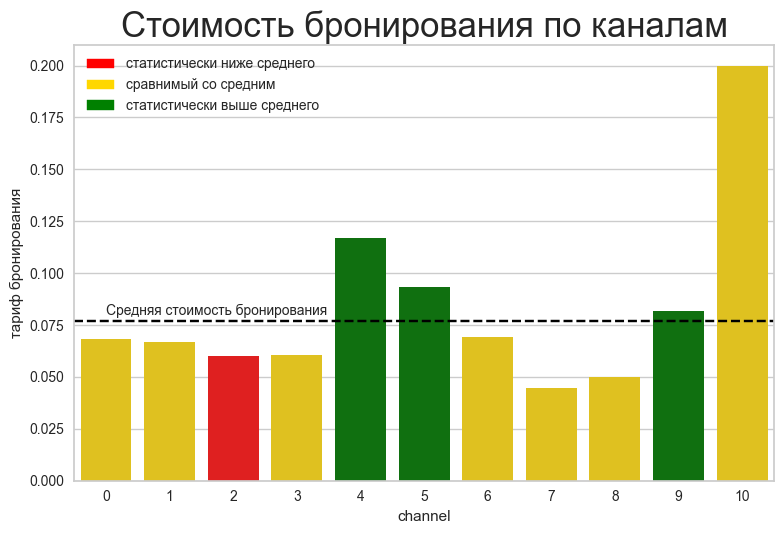

In [31]:
ax = sns.barplot(data=stats,x='channel',y='avg_booking',palette=['gold','gold','red','gold','green','green','gold','gold','gold','green','gold'])

ax.axhline(y=data['is_booking'].mean(),color='black',linestyle='--')
ax.text(0,0.08,'Средняя стоимость бронирования',fontsize=10)
ax.set_ylabel('тариф бронирования')

red_patch    = mpatches.Patch(color='red',label='статистически ниже среднего')
yellow_patch = mpatches.Patch(color='gold',label='сравнимый со средним')
green_patch  = mpatches.Patch(color='green',label='статистически выше среднего')
plt.legend(handles=[red_patch,yellow_patch,green_patch])

ax.set_title('Стоимость бронирования по каналам',size=25)

plt.tight_layout()

На графике показано сравнение общего показателя бронирования и показателя бронирования по каналам. Каналы, обозначенные зеленым цветом (4, 5 и 9), показали лучшие результаты, канал 2 – худшие, в то время как показатели каналов, обозначенных желтым цветом, статистически соответствуют средним значениям.

Может удивить классификация канала 10, который, хотя и значительно превосходит средний показатель бронирования, классифицируется как соответствующий ему. Это связано с тем, что количество бронирований на канале 10 составляет всего 3; следовательно, из-за малого количества, его результат не является статистически значимым.

# 3. Кластерный анализ
<a id="3"></a>

## 3.1 Функции для кластеризации

Выберем ряд признаков для кластеризации. В целом, этот выбор должен основываться на знаниях в предметной области бизнеса.

После выбора количества релевантных признаков сгруппируем данные по городу пользователя, а затем вычислим среднее значение переменных. Это своего рода среднее арифметическое по всем пользователям Expedia из этого города.

In [32]:
features = ['travel_duration',
            'days_in_advance',
            'orig_destination_distance',
            'srch_adults_cnt',
            'srch_children_cnt',
            'srch_rm_cnt']

city_data = data.dropna(axis=0)[features + ['user_location_city']]

city_groups = city_data.groupby('user_location_city').mean().reset_index().dropna(axis=0)

city_groups.head()

,user_location_city,travel_duration,days_in_advance,orig_destination_distance,srch_adults_cnt,srch_children_cnt,srch_rm_cnt
0,0,2.0000,78.50,2315.83625,1.7500,0.00,1.0
1,3,4.5625,92.25,3550.01750,1.9375,0.50,1.0
2,7,14.0000,58.00,5994.86400,2.0000,0.00,1.0
3,14,7.0000,35.75,5342.81910,2.0000,0.75,1.0
4,21,5.0000,31.50,2165.76890,1.5000,1.00,1.0


Из-за группировки размер нового датафрейма меньше, чем размер исходного датафрейма.

In [33]:
len(city_groups), len(data)

(4478, 96355)

После этого я смогу масштабировать переменные.

In [34]:
city_groups_scl = city_groups.copy()

scaler = MinMaxScaler() 

city_groups_scl[features] = scaler.fit_transform(city_groups_scl[features])

city_groups_scl.head()

,user_location_city,travel_duration,days_in_advance,orig_destination_distance,srch_adults_cnt,srch_children_cnt,srch_rm_cnt
0,0,0.025641,0.212329,0.202614,0.093750,0.00000,0.0
1,3,0.091346,0.250000,0.310612,0.117188,0.06250,0.0
2,7,0.333333,0.156164,0.524551,0.125000,0.00000,0.0
3,14,0.153846,0.095205,0.467493,0.125000,0.09375,0.0
4,21,0.102564,0.083562,0.189482,0.062500,0.12500,0.0


**Метод "локтя"**

Я использую метод "локтя" для прогнозирования оптимального числа кластеров.

In [35]:
inertia = []

for i in range(1,10):
    kmeans = KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(city_groups_scl[features])
    inertia.append(kmeans.inertia_)

k-means++ — это алгоритм для выбора начальных значений (или «семян») для алгоритма кластеризации k-средних.

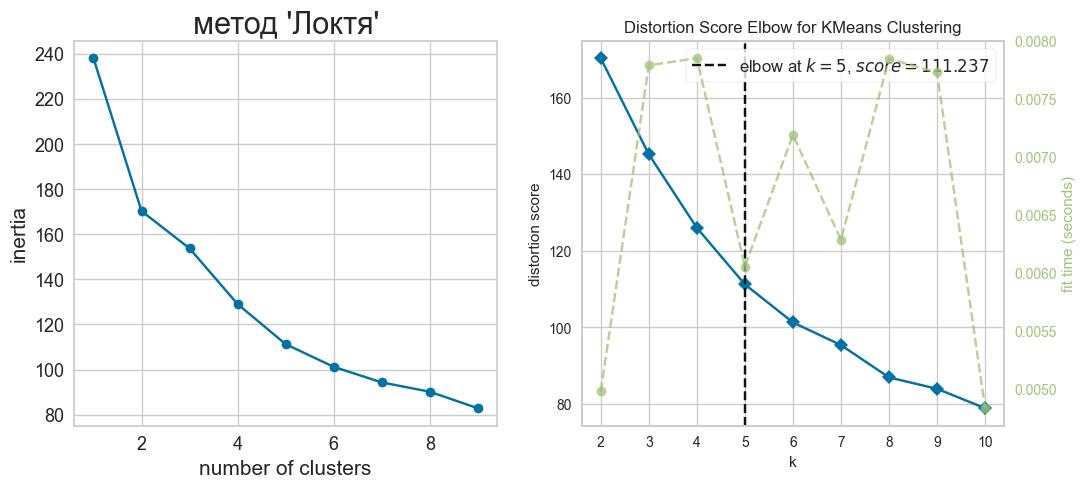

<Figure size 800x550 with 0 Axes>

In [36]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

ax1.plot(range(1,10),inertia,marker='o',linestyle='-')
ax1.xaxis.set_tick_params(labelsize=13)
ax1.yaxis.set_tick_params(labelsize=13)
ax1.set_xlabel("number of clusters",fontsize=15)
ax1.set_ylabel('inertia',fontsize=15)
ax1.set_title("метод 'Локтя'",fontsize=22)

Elbow_M = KElbowVisualizer(KMeans(), k=10, force_model=True)
Elbow_M.fit(city_groups_scl[features])
ax2 = Elbow_M.show()

plt.tight_layout() 

Опираясь на результаты, следует использовать k = 5.

**Silhouette score**

Еще один метод оценки оптимального числа кластеров — это использование **Silhouette score**.

In [39]:
silhouette_scores = []

range_clusters = range(2,11)

for i in range_clusters:
    kmeans = KMeans(n_clusters=i,random_state=0)
    labels = kmeans.fit_predict(city_groups_scl[features]) 
    score = silhouette_score(city_groups_scl[features],labels)
    silhouette_scores.append(score)

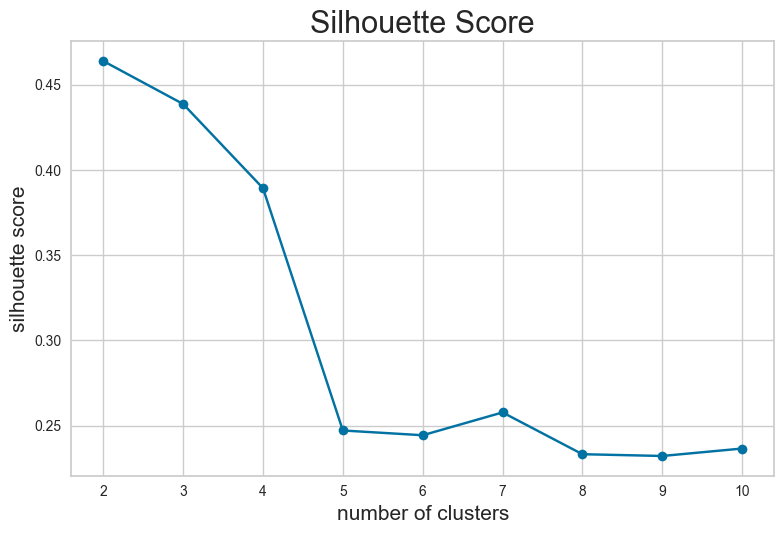

In [40]:
plt.plot(range_clusters,silhouette_scores,marker='o')
plt.xlabel("number of clusters",fontsize=15)
plt.ylabel('silhouette score',fontsize=15)
plt.title("Silhouette Score",fontsize=22)

plt.tight_layout()
plt.show()

Согласно анализу **Silhouette score**, k должно быть равно 4 или 5. Значения **Silhouette score** не очень высоки, но и не слишком низки. Посмотрим, сможем ли мы получить четко определенные кластеры.

## 3.2 Агломерация кластеров

### 3.2.1 Первый случай: k = 3

Провожу кластеризацию с использованием метода k-means.

In [42]:
km = cluster.KMeans(n_clusters=3,max_iter=100,random_state=None)

yhat = km.fit_predict(city_groups_scl[features])
city_groups_scl["clusters_2D"] = yhat

city_groups["clusters_2D"] = yhat

city_groups_scl.head()

,user_location_city,travel_duration,days_in_advance,orig_destination_distance,srch_adults_cnt,srch_children_cnt,srch_rm_cnt,clusters_2D
0,0,0.025641,0.212329,0.202614,0.093750,0.00000,0.0,0
1,3,0.091346,0.250000,0.310612,0.117188,0.06250,0.0,1
2,7,0.333333,0.156164,0.524551,0.125000,0.00000,0.0,1
3,14,0.153846,0.095205,0.467493,0.125000,0.09375,0.0,1
4,21,0.102564,0.083562,0.189482,0.062500,0.12500,0.0,0


Для визуализации кластеров на плоскости мне необходимо применить метод главных компонент (PCA), чтобы уменьшить размерность датафрейма до 2.

In [43]:
pca = PCA(n_components=2)

pca.fit(city_groups_scl[features]) 
city_groups_2D = pd.DataFrame(pca.transform(city_groups_scl[features]),columns=(["col1","col2"]))
city_groups_2D["clusters_2D"] = yhat
city_groups_2D.describe().T

,count,mean,std,min,25%,50%,75%,max
col1,4478.0,4.760224e-18,0.159786,-0.229839,-0.103307,-0.024091,0.056770,1.072509
col2,4478.0,2.702419e-18,0.106840,-0.505588,-0.047630,-0.008233,0.042246,0.628575
clusters_2D,4478.0,4.106744e-01,0.735180,0.000000,0.000000,0.000000,1.000000,2.000000


Теперь я наконец могу построить график распределения кластеров

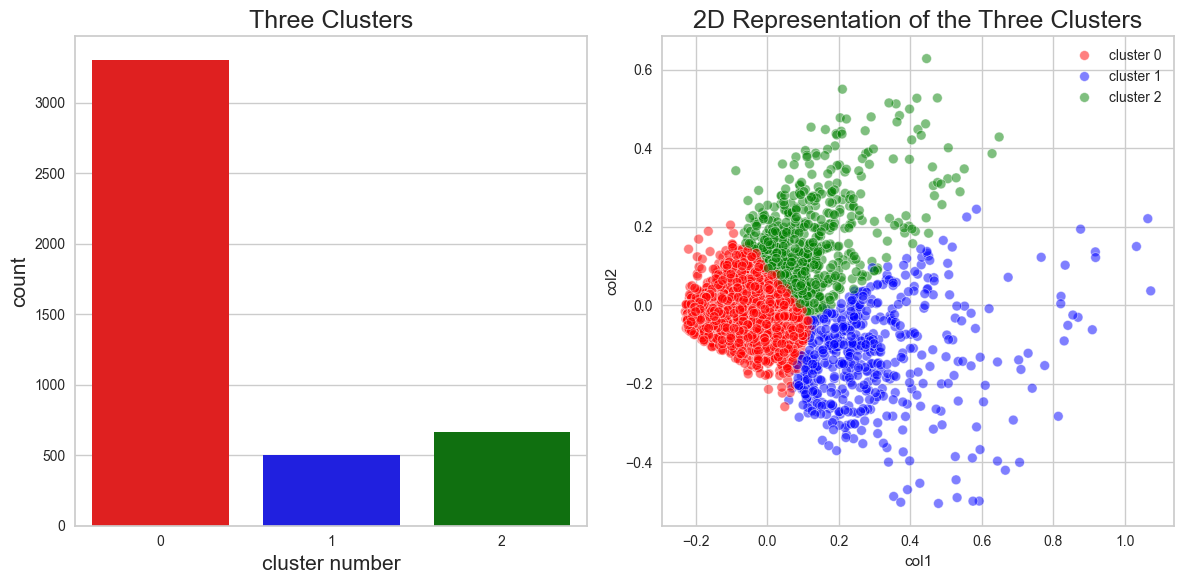

In [44]:
cluster_count = city_groups_2D.groupby("clusters_2D")["clusters_2D"].count().reset_index(name='count').sort_values(by='count',ascending=False)

fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,6))

ax1 = sns.barplot(x='clusters_2D',y='count',data=cluster_count,ax=ax1,palette=['red','blue','green'])
ax1.set_xlabel("cluster number",fontsize=15)
ax1.set_ylabel('count',fontsize=15)
ax1.set_title("Three Clusters",fontsize=18)

ax2 = sns.scatterplot(x="col1",y="col2",data=city_groups_2D,hue="clusters_2D",ax=ax2,palette=['red','blue','green'],alpha=0.5)
ax2.set_title("2D Representation of the Three Clusters",fontsize=18)
legend_handles,_ = ax2.get_legend_handles_labels()
ax2.legend(legend_handles,['cluster 0','cluster 1','cluster 2'])

plt.tight_layout()

Можно заметить, что соотношение трех полученных кластеров несбалансировано, но при этом кластеры четко разделены.

Посмотрим как выглядят эти кластеры в 3-х мерном пространстве.

In [45]:
pca = PCA(n_components=3)

pca.fit(city_groups_scl[features]) 
city_groups_3D = pd.DataFrame(pca.transform(city_groups_scl[features]),columns=(["col1","col2","col3"]))
city_groups_3D["clusters_3D"] = yhat
city_groups_3D.describe().T

,count,mean,std,min,25%,50%,75%,max
col1,4478.0,4.760224e-18,0.159786,-0.229839,-0.103307,-0.024091,0.056770,1.072509
col2,4478.0,2.702419e-18,0.106840,-0.505588,-0.047630,-0.008233,0.042246,0.628575
col3,4478.0,-1.318979e-17,0.085835,-0.239347,-0.036758,-0.011903,0.015783,0.986675
clusters_3D,4478.0,4.106744e-01,0.735180,0.000000,0.000000,0.000000,1.000000,2.000000


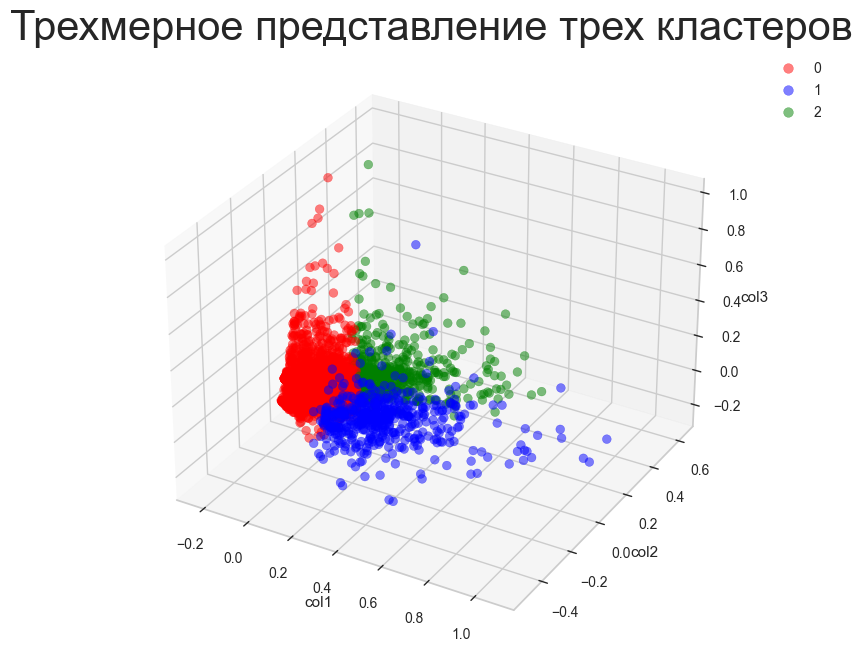

In [46]:
x = city_groups_3D['col1']
y = city_groups_3D['col2']
z = city_groups_3D['col3']
c = city_groups_3D["clusters_3D"]

fig = plt.figure(figsize=(6,6))

ax = Axes3D(fig,auto_add_to_figure=False)
fig.add_axes(ax)
ax.set_title('Трехмерное представление трех кластеров',size=30)

cmap = ListedColormap(sns.color_palette(palette=['red','blue','green']))

sc = ax.scatter(x,y,z,s=40,c=c,marker='o',cmap=cmap,alpha=0.5)
ax.set_xlabel('col1')
ax.set_ylabel('col2')
ax.set_zlabel('col3')

plt.legend(*sc.legend_elements(),bbox_to_anchor=(1.05,1),loc=2)

plt.tight_layout()

### 3.2.2 Второй случай: k = 5

In [47]:
city_groups_scl2 = city_groups_scl.copy()
city_groups2 = city_groups.copy()

km = cluster.KMeans(n_clusters=5,max_iter=100,random_state=None)

yhat2 = km.fit_predict(city_groups_scl2[features])
city_groups_scl2["clusters_2D"] = yhat2

city_groups2["clusters_2D"] = yhat2

city_groups_scl2.head()

,user_location_city,travel_duration,days_in_advance,orig_destination_distance,srch_adults_cnt,srch_children_cnt,srch_rm_cnt,clusters_2D
0,0,0.025641,0.212329,0.202614,0.093750,0.00000,0.0,0
1,3,0.091346,0.250000,0.310612,0.117188,0.06250,0.0,0
2,7,0.333333,0.156164,0.524551,0.125000,0.00000,0.0,4
3,14,0.153846,0.095205,0.467493,0.125000,0.09375,0.0,4
4,21,0.102564,0.083562,0.189482,0.062500,0.12500,0.0,0


In [48]:
pca = PCA(n_components=2)

pca.fit(city_groups_scl2[features]) 
city_groups_2D2 = pd.DataFrame(pca.transform(city_groups_scl2[features]),columns=(["col1","col2"]))
city_groups_2D2["clusters_2D"] = yhat2
city_groups_2D2.describe().T

,count,mean,std,min,25%,50%,75%,max
col1,4478.0,4.760224e-18,0.159786,-0.229839,-0.103307,-0.024091,0.056770,1.072509
col2,4478.0,2.702419e-18,0.106840,-0.505588,-0.047630,-0.008233,0.042246,0.628575
clusters_2D,4478.0,1.993971e+00,1.238648,0.000000,1.000000,2.000000,3.000000,4.000000


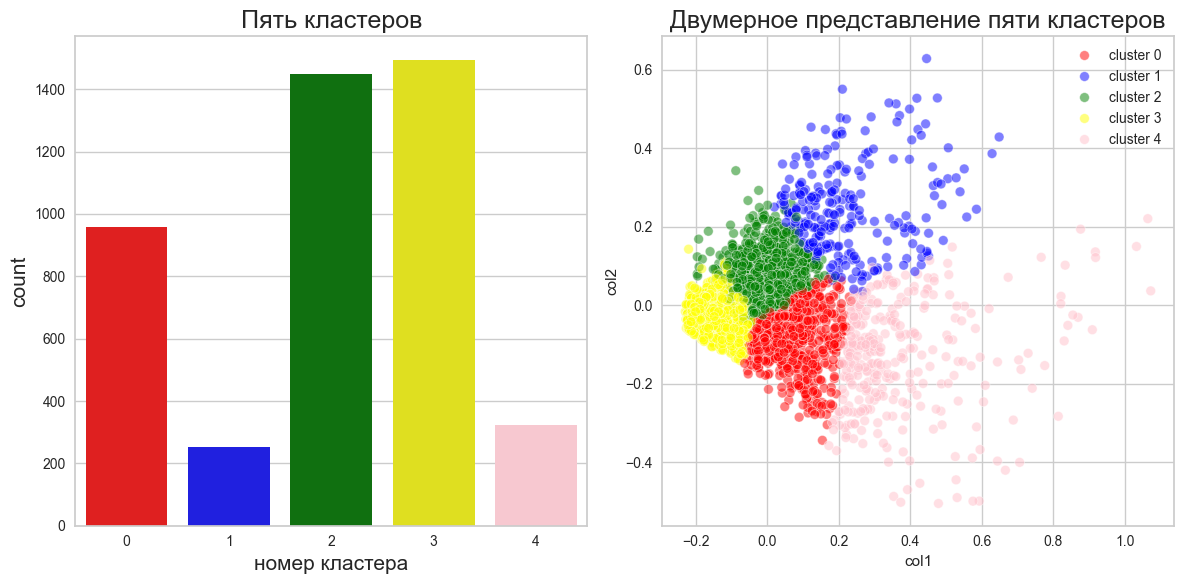

In [49]:
cluster_count2 = city_groups_2D2.groupby("clusters_2D")["clusters_2D"].count().reset_index(name='count').sort_values(by='count',ascending=False)

fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,6))

ax1 = sns.barplot(x='clusters_2D',y='count',data=cluster_count2,ax=ax1,palette=['red','blue','green','yellow','pink'])
ax1.set_xlabel("номер кластера",fontsize=15)
ax1.set_ylabel('count',fontsize=15)
ax1.set_title("Пять кластеров",fontsize=18)

ax2 = sns.scatterplot(x="col1",y="col2",data=city_groups_2D2,hue="clusters_2D",ax=ax2,palette=['red','blue','green','yellow','pink'],alpha=0.5)
ax2.set_title("Двумерное представление пяти кластеров",fontsize=18)
legend_handles,_ = ax2.get_legend_handles_labels()
ax2.legend(legend_handles,['cluster 0','cluster 1','cluster 2','cluster 3','cluster 4'])

plt.tight_layout()

Двумерное представление кластеров в случае k = 5 неудовлетворительно. Сравнивая правый график с графиком в случае k = 3, можно заметить, что два из пяти кластеров остались неизменными, в то время как остальные кластеры больше не принадлежат к одному и тому же кластеру, как в случае k = 3, а теперь разделены.

## 3.3 Проверка содержимого кластера (случай k = 3)

Для анализа содержимого различных кластеров я группирую данные по номеру кластера (0, 1 или 2), а затем усредняю ​​соответствующие признаки.

In [50]:
final_res = city_groups.groupby('clusters_2D')[['travel_duration','days_in_advance','orig_destination_distance','srch_adults_cnt','srch_children_cnt','srch_rm_cnt']].mean().reset_index()

final_res

,clusters_2D,travel_duration,days_in_advance,orig_destination_distance,srch_adults_cnt,srch_children_cnt,srch_rm_cnt
0,0,3.075816,39.805917,1308.741381,2.053650,0.376954,1.109272
1,1,4.469725,86.328294,5425.649601,2.040863,0.295039,1.097593
2,2,4.388301,127.539319,1749.303540,2.251956,0.392299,1.189781


Это средние значения продолжительности поездки, количества взрослых, количества детей и т.д. по трем группам.

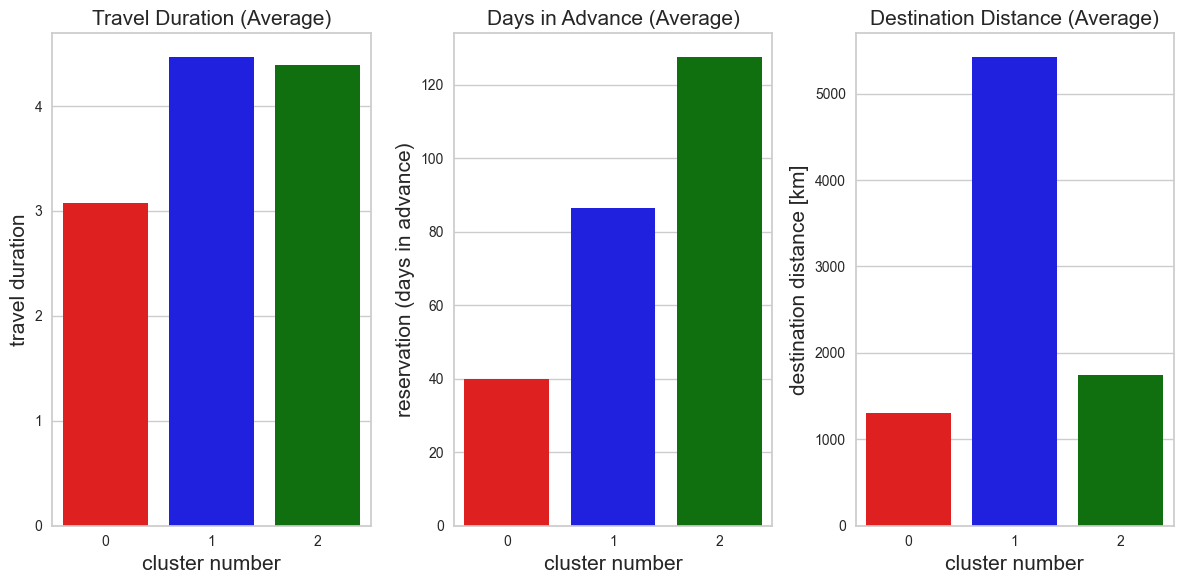

In [51]:
fig,(ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(12,6))

ax1 = sns.barplot(x='clusters_2D',y='travel_duration',data=final_res,ax=ax1,palette=['red','blue','green'])
ax1.set_xlabel("cluster number",fontsize=15)
ax1.set_ylabel('travel duration',fontsize=15)
ax1.set_title("Travel Duration (Average)",fontsize=15)

ax2 = sns.barplot(x='clusters_2D',y='days_in_advance',data=final_res,ax=ax2,palette=['red','blue','green'])
ax2.set_xlabel("cluster number",fontsize=15)
ax2.set_ylabel('reservation (days in advance)',fontsize=15)
ax2.set_title("Days in Advance (Average)",fontsize=15)

ax3 = sns.barplot(x='clusters_2D',y='orig_destination_distance',data=final_res,ax=ax3,palette=['red','blue','green'])
ax3.set_xlabel("cluster number",fontsize=15)
ax3.set_ylabel('destination distance [km]',fontsize=15)
ax3.set_title("Destination Distance (Average)",fontsize=15)

plt.tight_layout()

Как показано на графиках, клиенты, принадлежащие к трем кластерам, делают (в среднем) совершенно разные выборы:
1. Клиенты, принадлежащие к одному из кластеров, путешествуют 4-5 дней, бронируют билеты за 4 месяца вперед и проезжают менее 2000 километров. По моей личной интерпретации, клиенты этого кластера — это в основном пожилые люди (возможно, даже пенсионеры).
2. Клиенты другого (наиболее многочисленного) кластера путешествуют 3 дня, бронируют билеты за 40 дней вперед и проезжают чуть более 1000 километров. По моей интерпретации, это люди среднего класса в возрасте от 30 до 55/60 лет.
3. Клиенты последнего кластера путешествуют 4-5 дней, бронируют билеты за 3 месяца вперед и проезжают более 5000 километров. По моей интерпретации, это люди высшего класса или богатые люди.

# 4. Вывод по кластеризации
<a id="4"></a>

В работе были применены три метода кластеризации: KMeans, агломеративная кластеризация и кластеризация после снижения размерности с помощью PCA.
Для оценки качества кластеров использовались метрики силуэта и индекс Дэвиса–Болдина.

Лучшее качество кластеризации было получено при использовании метода KMeans, что подтверждается более высоким значением коэффициента силуэта и меньшим значением индекса Дэвиса–Болдина по сравнению с другими методами.

Визуализация кластеров в пространстве главных компонент показала, что объекты достаточно чётко разделяются на группы, что свидетельствует о наличии структуры в данных.